In [3]:
import pandas as pd

# Concatenate, Merge & Join

## concat()
- can be used for a simple concatenation of Series or DataFrame objects, just as np.concatenate() can be used for simple concatenations of arrays
- concat() makes a full copy of the data, and iteratively reusing concat() can create unnecessary copies. Collect all DataFrame or Series objects in a list before using concat().
- quickest way
- can work rowise or columnswise
- cons bc of duplication:
    - rowise(indices)
    - columnwise(column names)

### concat series

In [4]:
ser1 = pd.Series(['A', 'B', 'C'], index=[1, 2, 3])
ser1

1    A
2    B
3    C
dtype: object

In [5]:
ser2 = pd.Series(['D', 'E', 'F'], index=[4, 5, 6])
ser2

4    D
5    E
6    F
dtype: object

In [6]:
pd.concat([ser1, ser2])

1    A
2    B
3    C
4    D
5    E
6    F
dtype: object

### concat dataframes

In [7]:
df1 = pd.DataFrame(
    {
        "A": ["A0", "A1", "A2", "A3"],
        "B": ["B0", "B1", "B2", "B3"],
        "C": ["C0", "C1", "C2", "C3"],
        "D": ["D0", "D1", "D2", "D3"],
    },
    index=[0, 1, 2, 3],
)

df2 = pd.DataFrame(
    {
        "A": ["A4", "A5", "A6", "A7"],
        "B": ["B4", "B5", "B6", "B7"],
        "C": ["C4", "C5", "C6", "C7"],
        "D": ["D4", "D5", "D6", "D7"],
    },
    index=[4, 5, 6, 7],
)

df3 = pd.DataFrame(
    {
        "A": ["A8", "A9", "A10", "A11"],
        "B": ["B8", "B9", "B10", "B11"],
        "C": ["C8", "C9", "C10", "C11"],
        "D": ["D8", "D9", "D10", "D11"],
    },
    index=[8, 9, 10, 11],
)

frames = [df1, df2, df3]
result = pd.concat(frames)

result

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A4,B4,C4,D4
5,A5,B5,C5,D5
6,A6,B6,C6,D6
7,A7,B7,C7,D7
8,A8,B8,C8,D8
9,A9,B9,C9,D9


### concat([df1, df2, ...], join="outer/inner")
- The `join` keyword specifies how to handle axis values that don’t exist in the first DataFrame.
    - `join='outer'` takes the union of all axis values
    - `join='inner'` takes the intersection of the axis values
    - “left” join uses the exact index from the original DataFrame, result can be reindexed.

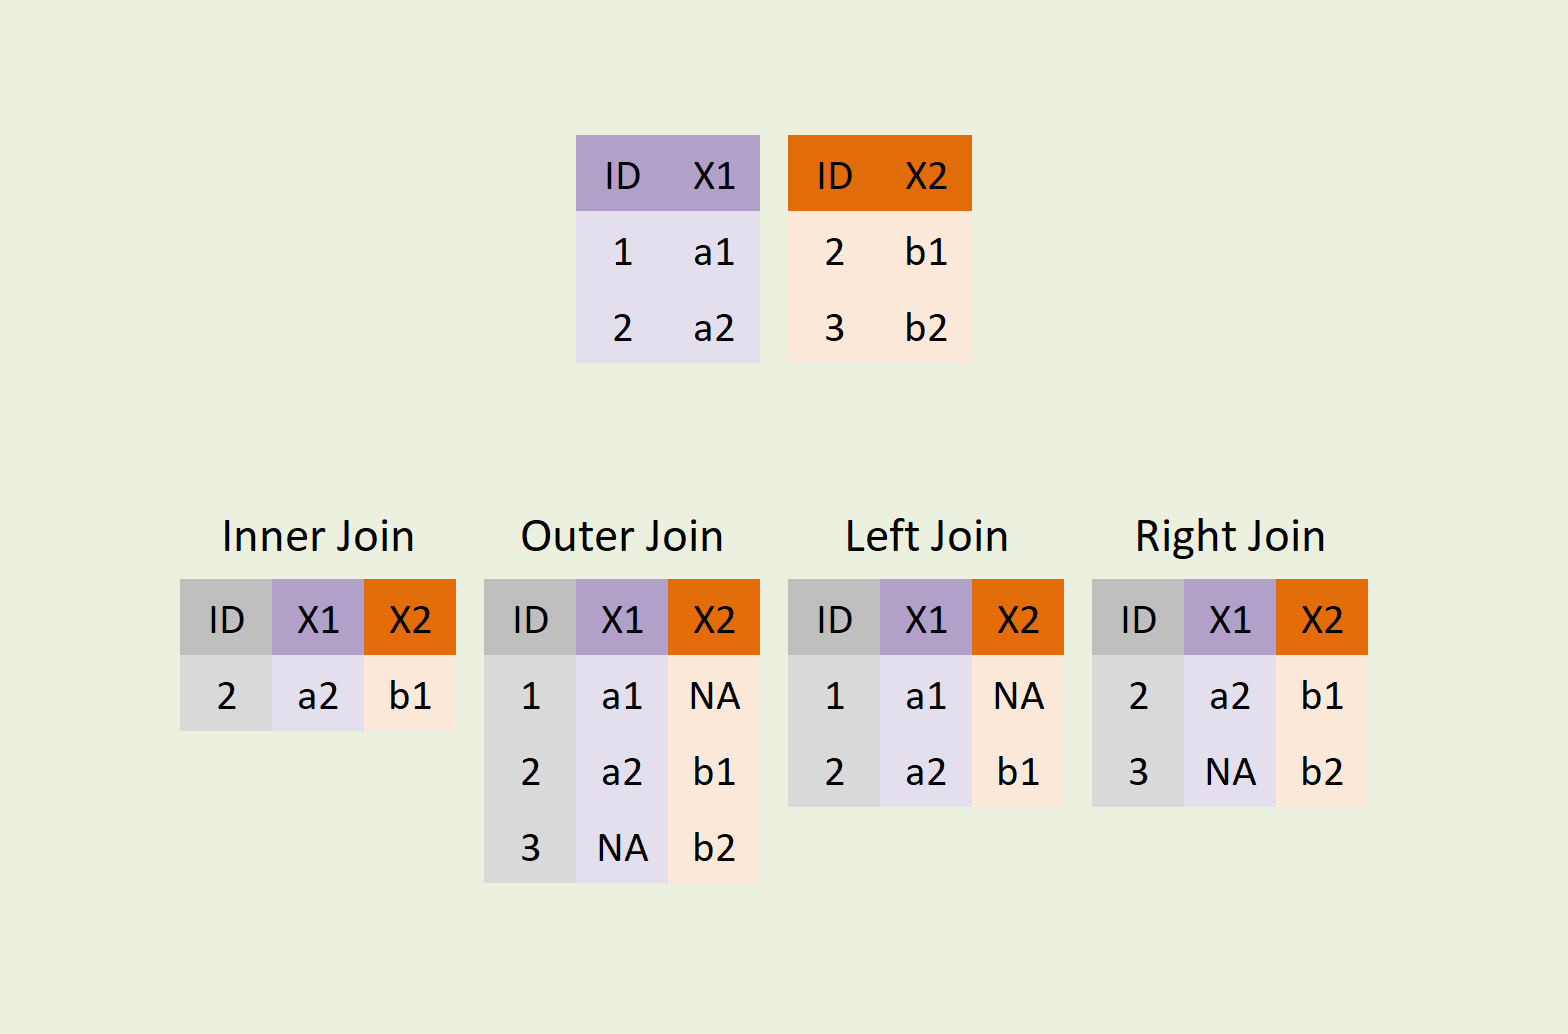


In [8]:
# outer join

df4 = pd.DataFrame(
    {
        "B": ["B2", "B3", "B6", "B7"],
        "D": ["D2", "D3", "D6", "D7"],
        "F": ["F2", "F3", "F6", "F7"],
    },
    index=[2, 3, 6, 7],
)

In [9]:
df1

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3


In [10]:
df4

,B,D,F
2,B2,D2,F2
3,B3,D3,F3
6,B6,D6,F6
7,B7,D7,F7


In [11]:
pd.concat([df1, df4]) # axis=0 is the default (along the rows/index)

,A,B,C,D,F
0,A0,B0,C0,D0,NaN
1,A1,B1,C1,D1,NaN
2,A2,B2,C2,D2,NaN
3,A3,B3,C3,D3,NaN
2,NaN,B2,NaN,D2,F2
3,NaN,B3,NaN,D3,F3
6,NaN,B6,NaN,D6,F6
7,NaN,B7,NaN,D7,F7


In [12]:
pd.concat([df1, df4], axis=1) #axis=1 (along the columns)

,A,B,C,D,B,D,F
0,A0,B0,C0,D0,NaN,NaN,NaN
1,A1,B1,C1,D1,NaN,NaN,NaN
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3
6,NaN,NaN,NaN,NaN,B6,D6,F6
7,NaN,NaN,NaN,NaN,B7,D7,F7


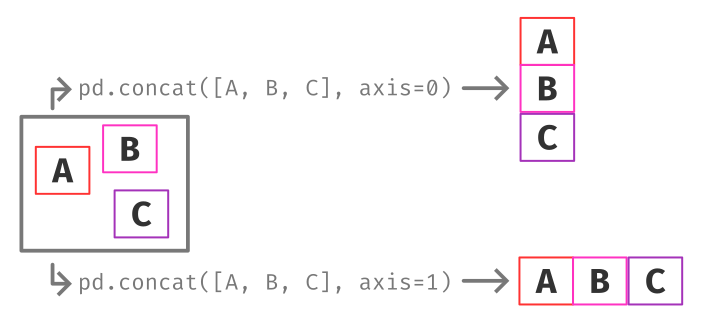

In [13]:
# inner join

pd.concat([df1, df4], axis=1, join="inner")

,A,B,C,D,B,D,F
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3


In [14]:
# left join

pd.concat([df1, df4], axis=1).reindex(df1.index)

,A,B,C,D,B,D,F
0,A0,B0,C0,D0,NaN,NaN,NaN
1,A1,B1,C1,D1,NaN,NaN,NaN
2,A2,B2,C2,D2,B2,D2,F2
3,A3,B3,C3,D3,B3,D3,F3


### concat series + dataframe
The Series will be transformed to DataFrame with the column name as the name of the Series.

In [15]:
s1 = pd.Series(["X0", "X1", "X2", "X3"], name=""X)
s1

SyntaxError: invalid syntax. Perhaps you forgot a comma? (596175354.py, line 1)

In [ ]:
df1

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3


In [ ]:
pd.concat([df1, s1], axis=1)

,A,B,C,D,X
0,A0,B0,C0,D0,X0
1,A1,B1,C1,D1,X1
2,A2,B2,C2,D2,X2
3,A3,B3,C3,D3,X3


### appending rows to a df
If you have a Series that you want to append as a single row to a DataFrame, you can convert the row into a DataFrame and use concat()

In [ ]:
s2 = pd.Series(["X0", "X1", "X2", "X3"], index=["A", "B", "C", "D"])
s2

A    X0
B    X1
C    X2
D    X3
dtype: object

In [ ]:
s2.to_frame() # convert to df

,0
A,X0
B,X1
C,X2
D,X3


In [ ]:
s2.to_frame().T # transpose

,A,B,C,D
0,X0,X1,X2,X3


In [ ]:
pd.concat([df1, s2.to_frame().T]) # concat, but index '0' is repeated

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
0,X0,X1,X2,X3


In [ ]:
pd.concat([df1, s2.to_frame().T], ignore_index=True)    # all in one

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,X0,X1,X2,X3


In [ ]:
df1.append(df2)

AttributeError: 'DataFrame' object has no attribute 'append'

For DataFrame objects which don’t have a meaningful index, the ignore_index ignores overlapping indexes.

# merge()
- database-style joins, like in sql
- flexibility in specifying
- 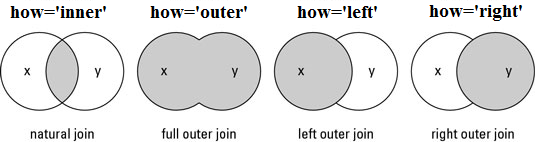

In [19]:
df1 = pd.DataFrame({
    'Stud_ID': [1, 2, 3, 4],
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Subject': ['Math', 'English', 'Science', 'History']
})

# Sample DataFrame 2
df2 = pd.DataFrame({
    'Stud_ID': [3, 4, 5, 6],
    'Score': [90, 85, 88, 92],
    'Grade': ['A', 'B', 'B+', 'A-']
})

In [20]:
df1

,Stud_ID,Name,Subject
0,1,Alice,Math
1,2,Bob,English
2,3,Charlie,Science
3,4,David,History


In [21]:
df2

,Stud_ID,Score,Grade
0,3,90,A
1,4,85,B
2,5,88,B+
3,6,92,A-


In [ ]:
pd.merge(left=df1,right=df2) # default is an inner join (param 'on' defaults to intersection of common columns)

,Stud_ID,Name,Subject,Score,Grade
0,3,Charlie,Science,90,A
1,4,David,History,85,B


In [23]:
pd.merge(left=df1,right=df2,on='Stud_ID',how='inner')

,Stud_ID,Name,Subject,Score,Grade
0,3,Charlie,Science,90,A
1,4,David,History,85,B


In [24]:
pd.merge(left=df1,right=df2,on='Stud_ID',how='left')

,Stud_ID,Name,Subject,Score,Grade
0,1,Alice,Math,NaN,NaN
1,2,Bob,English,NaN,NaN
2,3,Charlie,Science,90.0,A
3,4,David,History,85.0,B


In [25]:
pd.merge(left=df2,right=df1,on='Stud_ID',how='inner')

,Stud_ID,Score,Grade,Name,Subject
0,3,90,A,Charlie,Science
1,4,85,B,David,History


In [ ]:
# another way to perfect the merge
# order of naming the dfs determines column order?

df1.merge(df2, how='inner', on='Stud_ID')

,Stud_ID,Name,Subject,Score,Grade
0,3,Charlie,Science,90,A
1,4,David,History,85,B


In [27]:
df1 = pd.DataFrame({
    'Stud_ID': [1, 2, 3, 4],
    'Name': ['Alice', 'Bob', 'Charlie', 'David'],
    'Subject': ['Math', 'English', 'Science', 'History']
})

# Sample DataFrame 2
df2 = pd.DataFrame({
    'ID': [3, 4, 5, 6],
    'Score': [90, 85, 88, 92],
    'Grade': ['A', 'B', 'B+', 'A-']
})

In [28]:
pd.merge(left=df1,right=df2,how='inner', left_on="Stud_ID", right_on="ID")

,Stud_ID,Name,Subject,ID,Score,Grade
0,3,Charlie,Science,3,90,A
1,4,David,History,4,85,B


In [29]:
pd.merge(left=df1,right=df2,how='left', left_on="Stud_ID", right_on="ID")

,Stud_ID,Name,Subject,ID,Score,Grade
0,1,Alice,Math,NaN,NaN,NaN
1,2,Bob,English,NaN,NaN,NaN
2,3,Charlie,Science,3.0,90.0,A
3,4,David,History,4.0,85.0,B


In [30]:
pd.merge(left=df1,right=df2,how='right', left_on="Stud_ID", right_on="ID")

,Stud_ID,Name,Subject,ID,Score,Grade
0,3.0,Charlie,Science,3,90,A
1,4.0,David,History,4,85,B
2,NaN,NaN,NaN,5,88,B+
3,NaN,NaN,NaN,6,92,A-


In [32]:
data1 = pd.DataFrame({'lkey': ['foo', 'bar', 'baz', 'foo'],
                    'value': [1, 2, 3, 5]})
data2 = pd.DataFrame({'rkey': ['foo', 'bar', 'baz', 'foo'],
                    'value': [5, 6, 7, 8]})

In [33]:
data1

,lkey,value
0,foo,1
1,bar,2
2,baz,3
3,foo,5


In [34]:
data2

,rkey,value
0,foo,5
1,bar,6
2,baz,7
3,foo,8


In [ ]:
# inner join by default

data1.merge(data2, left_index=True, right_index=True)

,lkey,value_x,rkey,value_y
0,foo,1,foo,5
1,bar,2,bar,6
2,baz,3,baz,7
3,foo,5,foo,8


In [38]:
data1 = pd.DataFrame({'lkey': ['foo', 'bar', 'baz', 'foo'],
                    'value': [1, 2, 3, 5]}, index=[0,1,2,3])
data2 = pd.DataFrame({'rkey': ['foo', 'bar', 'baz', 'foo'],
                    'value': [5, 6, 7, 8]}, index=[1,2,3,4])

In [39]:
data1.merge(data2, left_index=True, right_index=True)

,lkey,value_x,rkey,value_y
1,bar,2,foo,5
2,baz,3,bar,6
3,foo,5,baz,7


In [40]:
data1.merge(data2, left_index=True, right_index=True, how='left')

,lkey,value_x,rkey,value_y
0,foo,1,NaN,NaN
1,bar,2,foo,5.0
2,baz,3,bar,6.0
3,foo,5,baz,7.0


In [ ]:
data1.merge(data2, left_index=True, right_index=True, how='right')  # new column is a float???

,lkey,value_x,rkey,value_y
1,bar,2.0,foo,5
2,baz,3.0,bar,6
3,foo,5.0,baz,7
4,NaN,NaN,foo,8


# join
- convenient shorthand, *focussing on indices/row-labels* rather than columns
- works best with unique index columns e.g. sales across dates

In [44]:
df1

,Stud_ID,Name,Subject
0,1,Alice,Math
1,2,Bob,English
2,3,Charlie,Science
3,4,David,History


In [45]:
df2

,ID,Score,Grade
0,3,90,A
1,4,85,B
2,5,88,B+
3,6,92,A-


In [ ]:
df1.set_index("Stud_ID", inplace=True)

In [55]:
df1

,Name,Subject
Stud_ID,,
1,Alice,Math
2,Bob,English
3,Charlie,Science
4,David,History


In [ ]:
df2.set_index("ID",inplace=True)

In [56]:
df2

,Score,Grade
ID,,
3,90,A
4,85,B
5,88,B+
6,92,A-


In [50]:
df1.join(df2, how='inner')

,Name,Subject,Score,Grade
3,Charlie,Science,90,A
4,David,History,85,B


In [51]:
df1.join(df2, how='outer')

,Name,Subject,Score,Grade
1,Alice,Math,NaN,NaN
2,Bob,English,NaN,NaN
3,Charlie,Science,90.0,A
4,David,History,85.0,B
5,NaN,NaN,88.0,B+
6,NaN,NaN,92.0,A-
